# Comparativa de Clasificación de Frutas con Deep Learning: CNN desde Cero vs ResNet50 Preentrenada

## Resumen Ejecutivo del Proyecto
Proyecto de clasificación de imágenes aplicado a retail alimentario usando Deep Learning sobre un subconjunto del Grocery Store Dataset. Se comparó una CNN construida desde cero contra un modelo preentrenado `ResNet50`, integrando datos almacenados en Azure Blob Storage y un flujo completo de preparación, entrenamiento y evaluación.

## Problema
El objetivo fue identificar cuál enfoque clasifica mejor imágenes de productos —Apple, Avocado y Banana— bajo un escenario realista de desbalance de clases, y medir el beneficio de usar transferencia de aprendizaje frente a una arquitectura propia.

## Enfoque técnico
Se diseñó un pipeline end-to-end con lectura de imágenes y metadatos desde Azure, preprocesamiento con `TensorFlow`, redimensionamiento a 100x100 píxeles y normalización compatible con `ResNet50`. Para mitigar el desbalance, se aplicó data augmentation con rotación, zoom, desplazamientos, brillo y flip horizontal. Luego se entrenaron dos modelos: una CNN profunda personalizada y `ResNet50` congelando la base preentrenada y ajustando solo el clasificador final. La evaluación incluyó accuracy, weighted F1-score, classification report y matrices de confusión.

## Resultados Principales
`ResNet50` obtuvo el mejor desempeño global con 97.22% de accuracy y 0.9708 de weighted F1, superando a la CNN personalizada, que alcanzó 94.17% de accuracy y 0.9421 de weighted F1. El modelo preentrenado `ResNet50` clasificó mejor las clases: Apple y Banana. Los resultados sugieren que la transferencia de aprendizaje mejora precisión en las predicciones.

## Valor para Portafolio
Demuestra competencias relevantes para roles de ciencia de datos: procesamiento de imgénes, construcción de red neuronal supervisada, uso de arquiecturas pre-entrenadas y transferencia de aprendizaje, tratamiento de datos desbalanceados, evaluación comparativa de modelos y uso de servicios cloud para ingestión de datos.

In [1]:
#!pip install seaborn matplotlib tensorflow scikit-learn azure-identity azure-storage-blob

In [2]:
#%pip install cv2

# Descripción del Reto

- Este reto busca que los estudiantes comparen el rendimiento de la Red CNN vista en clase DL_Semana2_GroceryStore, con una red preentrenada ResNet50 o MobileNetV2 (a elección del estudiante). El propósito es analizar como los modelos preentrenados se comportan respecto a una red construida desde cero en el dataset trabajado en clase.
- Elige uno de los dos modelos ResNet50 ó MobileNetV2, y luego, agrega capas extra a un clasificador final, por ejemplo: GlobalAveragePooling2D + Dense softmax.
- Entrenar solo el clasificador final.
- El alumno deberá escribir un pequeño análisis respondiendo:
  
**1. ¿Cuál modelo obtuvo mejor f1-score y por qué?**
- ResNet50 obtuvo el mejor weighted F1 = 0.9708, versus 0.9421 de la CNN.
- Esta mejora se puede explicar por el mejor performance de ResNet50 para clasificar correctamente la clase Apple y Banana.

**2. ¿Qué tan diferente fue el tiempo de entrenamiento?**

- A continuación se muestra que el modelo CNN necesitó más épocas de entretamiento y por tanto su tiempo de entrenamiento fue mayor.

- CNNmodel:
  Parámetros: 456,899
  Épocas: 24
  Tiempo total: 1285.1s (53.5s/época)

- ResNet50model:
  Parámetros: 24,178,819
  Épocas: 11
  Tiempo total: 533.8s (48.5s/época)


**3. ¿Qué ventajas observas al usar modelos preentrenados?**

- Convergencia más rápida en el entrenamiento.
- Mejor desempeño en la clasificación.

**4. ¿Hay riesgo de sobre ajuste en alguno de los modelos?**

- Sí, ambos modelos muestran un accuracy casi perfecto para el set de entrenamiento, sin embargo la clase Avocado (ResNet50) y Banana (CNN ) son las más díficiles de predecir para cada modelo, en el set de test.

In [3]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

In [4]:
# Manipulación de datos e imagenes
import io
import cv2
import numpy as np
import pandas as pd

# Computo en la nube de azure
from azure.identity import DefaultAzureCredential
from azure.storage.blob import BlobServiceClient

# Deep Learninf con tensorflow y keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras import layers, models, applications
from tensorflow.keras.regularizers import l2

from collections import Counter

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score, confusion_matrix

# Visualización
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.ticker import FuncFormatter

import time


2026-03-06 04:13:26.535346: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-06 04:13:26.535408: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-06 04:13:26.537103: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-06 04:13:26.546401: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-06 04:13:27.768016: W tensorflow/comp

In [5]:
# Set style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# 1. Dataset

https://www.kaggle.com/datasets/validmodel/grocery-store-dataset/data

## Configure Azure Blob Storage Connection

In [6]:
# Azure Blob Storage configuration
account_name = "grocerydataset01"
container_name = "dataset"

# Create BlobServiceClient using DefaultAzureCredential
url = f"https://{account_name}.blob.core.windows.net"
credential = DefaultAzureCredential()
blob_service_client = BlobServiceClient(account_url=url, credential=credential)
container_client = blob_service_client.get_container_client(container=container_name)

print(f"Connected to: {url}")
print(f"Container: {container_name}")

Connected to: https://grocerydataset01.blob.core.windows.net
Container: dataset


## Read CSV File from Blob Storage

In [7]:
# Function to read a blob file as DataFrame
def read_blob_as_csv(blob_name, names=None, delimiter=' '):
    blob_client = container_client.get_blob_client(blob=blob_name)
    blob_data = blob_client.download_blob().readall()
    
    if names:
        df = pd.read_csv(io.BytesIO(blob_data), names=names, delimiter=delimiter)
    else:
        df = pd.read_csv(io.BytesIO(blob_data))
    
    return df

## Read  IMG File from Blob Storage

In [8]:
# Function to read image from blob storage
def read_image_from_blob(blob_name):
    blob_client = container_client.get_blob_client(blob=blob_name)
    blob_data = blob_client.download_blob().readall()
    
    # Convert bytes to numpy array
    nparr = np.frombuffer(blob_data, np.uint8)
    
    # Decode image
    image = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
    return image

# IMG procesamiento

In [9]:
# Function to load and preprocess images from a list of paths
def load_images_from_folder(paths, data_dir, img_size=(100, 100)):
    image_ds = []
    for path in paths:
        s = data_dir + '/' + path
        img = read_image_from_blob(s)
        resized = cv2.resize(img,img_size)
        image_ds.append(resized)
        
    image_array = np.array(image_ds)
    X = preprocess_input(image_array)
    return X

In [10]:
# Lectura de paths del set train/ test /val con filtro por clases seleccionadas
def read_paths(blob_name, selected_classes):
    df_paths = read_blob_as_csv(blob_name, names=["path", "fine" ,"coarse"], delimiter=',')
    # Filtrar por clases seleccionadas
    df_filtered = df_paths[df_paths["coarse"].isin(selected_classes)]
    return df_filtered

In [11]:
class DataAugmentationBalancer:
    """
    Clase para balancear dataset aplicando augmentación de datos.
    
    Realiza oversampling dinámico usando transformaciones de imágenes
    (rotación, zoom, cambio de brillo, etc.) para que cada clase tenga
    aproximadamente el mismo número de muestras.
    """
    
    def __init__(self, rotation_range=50, target_per_class=1500, seed=42):
        """
        Inicializa el balanceador con los parámetros de augmentación.
        
        Args:
            rotation_range (int): Rango de rotación en grados (0-360)
            target_per_class (int): Número objetivo de muestras por clase
            seed (int): Semilla para reproducibilidad
        """
        # Crear generador de transformaciones para augmentar imágenes
        self.datagen = ImageDataGenerator(
            rotation_range=rotation_range,              # Rotación aleatoría
            width_shift_range=0.1,                       # Desplazamiento horizontal
            height_shift_range=0.1,                      # Desplazamiento vertical
            zoom_range=0.2,                              # Zoom aleatorio
            horizontal_flip=True,                        # Volteo horizontal
            brightness_range=[0.8, 1.2],                 # Variación de brillo
            fill_mode='nearest'                          # Relleno de píxeles vacíos
        )
        self.target_per_class = target_per_class  # Muestras deseadas por clase
        self.seed = seed                           # Semilla para reproducibilidad
    
    def balancear(self, X_train, y_train):
        """
        Aplica data augmentation para balancear las clases.
        
        Itera sobre cada clase y genera imágenes sintéticas hasta 
        alcanzar el número objetivo.
        
        Args:
            X_train (np.ndarray): Array de imágenes de entrenamiento
            y_train (np.ndarray): Array de etiquetas de entrenamiento
            
        Returns:
            tuple: (X_aug, y_aug) - Imágenes y etiquetas augmentadas
        """
        X_aug = []  # Lista para almacenar imágenes augmentadas
        y_aug = []  # Lista para almacenar etiquetas de imágenes augmentadas
        
        # Iterar sobre cada clase única en el dataset
        for cls in np.unique(y_train):
            # Obtener índices de muestras pertenecientes a esta clase
            idx = np.where(y_train == cls)[0]
            # Extraer solo las imágenes de esta clase
            X_cls = X_train[idx]
            # Calcular cuántas imágenes sintéticas se necesitan
            n_to_generate = self.target_per_class - len(X_cls)
            
            # Generar imágenes solo si la clase necesita más muestras
            if n_to_generate > 0:
                print(f"Clase {cls}: {n_to_generate} imágenes")
                # Crear generador que produce transformaciones aleatorias
                gen = self.datagen.flow(X_cls, batch_size=1, seed=self.seed)
                
                # Generar y almacenar las imágenes sintéticas
                for _ in range(n_to_generate):
                    # Obtener siguiente imagen transformada del generador
                    new_img = next(gen)[0]
                    X_aug.append(new_img)      # Agregar imagen augmentada
                    y_aug.append(cls)           # Agregar etiqueta correspondiente
        
        # Convertir listas a arrays numpy para consistencia
        return np.array(X_aug), np.array(y_aug)

In [12]:
class ImageClassifierArchitectures:
    """
    Clase que proporciona dos arquitecturas de Redes Neuronales Convolucionales
    para clasificación de imágenes usando Keras Sequential API.
    
    Las arquitecturas incluyen:
    - CNN Profunda: Modelo con mayor capacidad de representación
    - ResNet50: Modelo preentrenado con transferencia de aprendizaje
    """
    
    def __init__(self, input_shape=(100, 100, 3), num_classes=3):
        """
        Inicializa el constructor de arquitecturas.
        
        Args:
            input_shape (tuple): Dimensiones de las imágenes de entrada (alto, ancho, canales)
            num_classes (int): Número de clases para clasificación
        """
        self.input_shape = input_shape
        self.num_classes = num_classes
    
    def crear_cnn(self):
        """
        Crea una CNN simple para clasificación de imágenes.
        
        Arquitectura:
        - 3 convolucionales (Conv2D + MaxPooling)
        - 1 convolucional (Conv2D + GlobalAveragePooling)
        - 2 capas densas para clasificación
        
        Returns:
            models.Sequential: Modelo compilado listo para entrenar
        """
        modelo = models.Sequential([
            layers.Input(shape=self.input_shape),
            layers.Conv2D(32, (3, 3), padding='same'),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.MaxPooling2D(),

            layers.Conv2D(64, (3, 3), padding='same'),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.MaxPooling2D(),

            layers.Conv2D(128, (3, 3), padding='same'),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.MaxPooling2D(),

            layers.Conv2D(256, (3, 3), padding='same'),
            layers.BatchNormalization(),
            layers.ReLU(),
            layers.GlobalAveragePooling2D(),

            layers.Dense(256, activation='relu'),
            layers.Dropout(0.2),
            layers.Dense(self.num_classes, activation='softmax')
        ])

        modelo.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        return modelo
    
    def crear_resnet50(self):
        """
        Crea un modelo basado en ResNet50 preentrenado para clasificación de imágenes.
        
        Arquitectura:
        - ResNet50 sin la capa de clasificación final (transferencia de aprendizaje)
        - Capa Global Average Pooling para reducir dimensiones
        - 2 capas densas con Dropout para clasificación
        
        Returns:
            models.Sequential: Modelo compilado listo para entrenar
        """
        base_model = ResNet50(
            input_shape=self.input_shape,
            include_top=False,
            weights='imagenet'
        )
        base_model.trainable = False

        x = layers.GlobalAveragePooling2D()(base_model.output)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.3)(x)
        # Capa de salida con softmax
        outputs = layers.Dense(self.num_classes, activation="softmax")(x)

               
        modelo = models.Model(base_model.input, outputs)
        
        # Compilar el modelo 
        modelo.compile(
            optimizer='adam',   # Optimizador Adam
            loss='sparse_categorical_crossentropy',                    # Pérdida para clasificación multiclase
            metrics=['accuracy']                                       # Métrica de evaluación
        )
        
        return modelo

In [13]:
# Inicialización de variables
data_dir = "dataset"
# Tamaño de imagenes para el modelo
img_size = (100, 100)
seed = 42

In [14]:
# Read classes.csv file from blob storage
blob_name = data_dir + "/classes.csv"
df_classes = read_blob_as_csv(blob_name)

print(f"Loaded: {blob_name}")
print(f"Shape: {df_classes.shape}")
print("\nFirst 5 rows:")
print(df_classes.head())

Loaded: dataset/classes.csv
Shape: (81, 6)

First 5 rows:
   Class Name (str)  Class ID (int) Coarse Class Name (str)  \
0  Golden-Delicious               0                   Apple   
1      Granny-Smith               1                   Apple   
2         Pink-Lady               2                   Apple   
3     Red-Delicious               3                   Apple   
4        Royal-Gala               4                   Apple   

   Coarse Class ID (int)                            Iconic Image Path (str)  \
0                      0  /iconic-images-and-descriptions/Fruit/Apple/Go...   
1                      0  /iconic-images-and-descriptions/Fruit/Apple/Gr...   
2                      0  /iconic-images-and-descriptions/Fruit/Apple/Pi...   
3                      0  /iconic-images-and-descriptions/Fruit/Apple/Re...   
4                      0  /iconic-images-and-descriptions/Fruit/Apple/Ro...   

                      Product Description Path (str)  
0  /iconic-images-and-description

In [15]:
# 1) Definimos las columnas que necesitamos para construir el 
# mapeo Clase ID -> Clase name
required_cols = ["Coarse Class ID (int)", "Coarse Class Name (str)"]

# 2) Verificamos si falta alguna columna esperada en el DataFrame
missing_cols = [col for col in required_cols if col not in df_classes.columns]

if missing_cols:
    raise KeyError(f"Missing required columns in df_classes: {missing_cols}")

# 3) Construimos el diccionario coarse_mapping 
coarse_mapping = (
    # Selecciona solo las columnas relevantes
    df_classes[required_cols]
    # Elimina filas con valores nulos en las columnas clave
    .dropna(subset=required_cols)
    # Si hay IDs repetidos, conserva la primera ocurrencia
    .drop_duplicates(subset=["Coarse Class ID (int)"], keep="first")
    # Usa el ID como índice y la columna de clase como valor
    .set_index("Coarse Class ID (int)")["Coarse Class Name (str)"]
    # Convierte la serie resultante en diccionario
    .to_dict()
)

# 4) Muestra cuántas clases gruesas quedaron mapeadas
print(f"Clases mapeadas: {len(coarse_mapping)}")

Clases mapeadas: 43


In [16]:
# Extrae de las clases con id 0,1,2. 
#1) Acces class [0,1,2]
#2) Guarda el nombre de la clase 
coarse_mapping_subset = {c_id: c_name for c_id, c_name in coarse_mapping.items() if c_id in [0,1,2]}
print("Clases seleccionadas:")
for c_id, c_name in coarse_mapping_subset.items():
    print(f"{c_id}: {c_name}")

Clases seleccionadas:
0: Apple
1: Avocado
2: Banana


In [17]:
df_train = read_paths(data_dir + "/train.txt", coarse_mapping_subset.keys())
df_val = read_paths(data_dir + "/val.txt", coarse_mapping_subset.keys())
df_test = read_paths(data_dir + "/test.txt", coarse_mapping_subset.keys())
print(f"Train samples: \n {df_train.sample(5)}")

Train samples: 
                                                   path  fine  coarse
66   train/Fruit/Apple/Granny-Smith/Granny-Smith_02...     1       0
129      train/Fruit/Apple/Pink-Lady/Pink-Lady_026.jpg     2       0
214    train/Fruit/Apple/Royal-Gala/Royal-Gala_002.jpg     4       0
329                  train/Fruit/Banana/Banana_011.jpg     6       2
142      train/Fruit/Apple/Pink-Lady/Pink-Lady_039.jpg     2       0


Image shape: (348, 348, 3)


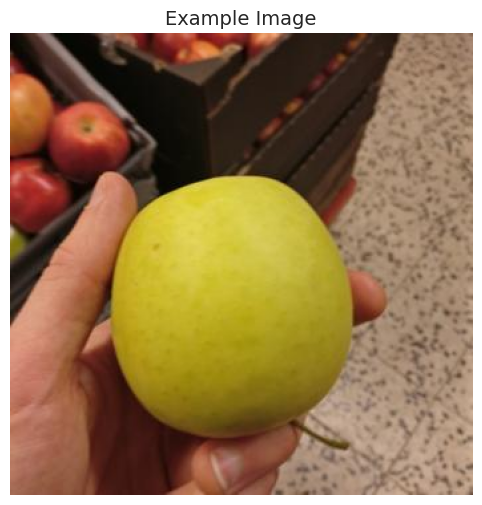

In [18]:
# Lectura de una imagen
image  = read_image_from_blob(data_dir + '/train/Fruit/Apple/Golden-Delicious/Golden-Delicious_001.jpg')
print(f"Image shape: {image.shape}")

# Muestra imagen ejemplo
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.title("Example Image")
plt.axis("off")
plt.show()

In [19]:
df_train["coarse_name"] = df_train["coarse"].map(coarse_mapping)
counts = df_train["coarse_name"].value_counts()
print(counts)


Apple      278
Banana      45
Avocado     41
Name: coarse_name, dtype: int64


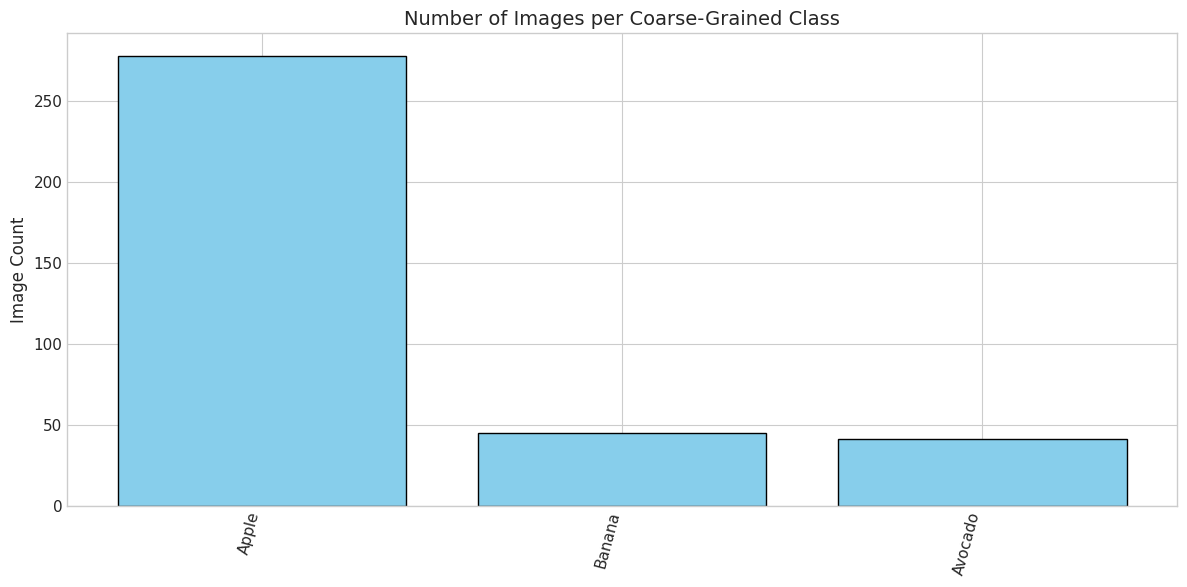

In [20]:
plt.figure(figsize=(12, 6))
plt.bar(counts.index, counts.values, color="skyblue", edgecolor="black")
plt.title("Number of Images per Coarse-Grained Class", fontsize=14)
plt.ylabel("Image Count")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

In [21]:
# Objeto X de imagenes para entrenamiento
X_train = load_images_from_folder(df_train['path'].values, data_dir)
# DImensiones
print(X_train.shape)

X_val = load_images_from_folder(df_val['path'].values, data_dir)
print(X_val.shape)
      
X_test = load_images_from_folder(df_test['path'].values, data_dir)
print(X_test.shape)

(364, 100, 100, 3)
(33, 100, 100, 3)
(360, 100, 100, 3)


In [22]:
#print("Dataset >>> ", X_train)
print("Sample >>> ", X_train[0])
print("Sample shape Height x Width x Channels >>> ", X_train[0].shape)

Sample >>>  [[[ -85.939     -109.779     -113.68     ]
  [ -82.939     -104.779     -113.68     ]
  [ -75.939      -99.779     -113.68     ]
  ...
  [  43.060997    -0.7789993  -28.68     ]
  [  56.060997    12.221001   -15.68     ]
  [  41.060997    -2.7789993  -30.68     ]]

 [[ -90.939     -108.779     -118.68     ]
  [ -88.939     -104.779     -116.68     ]
  [ -83.939     -100.779     -116.68     ]
  ...
  [  32.060997   -11.778999   -40.68     ]
  [  50.060997     6.2210007  -21.68     ]
  [  57.060997    13.221001   -14.68     ]]

 [[ -93.939     -110.779     -122.68     ]
  [ -91.939     -105.779     -120.68     ]
  [ -85.939      -97.779     -114.68     ]
  ...
  [  42.060997    -1.7789993  -29.68     ]
  [  53.060997     9.221001   -18.68     ]
  [  66.061       22.221       -4.6800003]]

 ...

 [[  64.061       -9.778999   -37.68     ]
  [  59.060997   -14.778999   -42.68     ]
  [  56.060997   -17.779      -45.68     ]
  ...
  [  23.060997   -15.778999   -45.68     ]
  [  9

In [23]:
# Objeto y de etiquetas para entrenamiento
y_train = np.array(df_train['coarse'])
y_val = np.array(df_val['coarse'])
y_test = np.array(df_test['coarse'])

In [24]:
# Balanceo de clases con data augmentation
cls_balancer = DataAugmentationBalancer(target_per_class=1500)
X_train_balanced, y_train_balanced = cls_balancer.balancear(X_train, y_train)

Clase 0: 1222 imágenes
Clase 1: 1459 imágenes
Clase 2: 1455 imágenes


In [25]:
print(Counter(y_train_balanced))

Counter({1: 1459, 2: 1455, 0: 1222})


In [26]:
# Generate a random permutation of indices
permutation = np.random.permutation(len(X_train_balanced))

# Apply the permutation to both X and y
X_train_balanced = X_train_balanced[permutation]
y_train_balanced = y_train_balanced[permutation]

In [27]:
# Compilar modelos
archs = ImageClassifierArchitectures(input_shape=(100, 100, 3), num_classes=3)
cnn_model = archs.crear_cnn()
cnn_model.name = "CNNmodel"
resnet_model = archs.crear_resnet50()
resnet_model.name = "ResNet50model"

2026-03-06 04:13:52.339184: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [28]:
history_dict = {}
results = []
model_paths = []
epochs_max = 100

batch_size = 32

# Entrenar modelos 
model_configs = [
    (cnn_model, cnn_model.name),
    (resnet_model, resnet_model.name)
]

for model, name in model_configs:
    print(f"\n{'='*50}")
    print(f"Entrenando {name}")
    print(f"{'='*50}")
    start_time = time.time()


    # Save best model callback
    checkpoint_path = name +'_all_train_imgs_best.h5'
    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        save_best_only=True,
        monitor='val_loss',
        mode='min',
        verbose=1
    )

    history = model.fit(
        X_train_balanced, 
        y_train_balanced,
        validation_data=(X_val, y_val),
        epochs=epochs_max,
        batch_size=batch_size,
        callbacks=[
            checkpoint,
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=10, 
                restore_best_weights=True,
                verbose=1
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                factor=0.3, 
                patience=5,
                verbose=1
            )
        ],
        verbose=1,
    )

    train_time = time.time() - start_time

    train_loss = history.history['loss']
    val_loss = history.history['val_loss']
    train_acc = history.history.get('accuracy', [])
    val_acc = history.history.get('val_accuracy', [])
    epochs_range = range(len(history.history['loss']))

    epochs_entrenadas = len(train_loss)
    epochs_range = range(epochs_entrenadas)
    best_val_loss = min(val_loss)
    best_epoch = np.argmin(val_loss) + 1

    # Guardar historia
    history_dict[name] = history.history

    # Guardar mejor modelo
    model_paths.append(checkpoint_path)  # Use best model path
    print(f"Best model saved to: {checkpoint_path}")

   # Metrics
    results.append({
        'Modelo': name,
        'Train_Loss': train_loss,
        'Val_Loss': val_loss,
        'Train_Acc': train_acc,
        'Val_Acc': val_acc,
        'Epochs_range': epochs_range,
        'Epochs_entrenadas': epochs_entrenadas,
        'Train_Time (s)': train_time,
        'Time_per_epoch (s)': train_time / epochs_entrenadas,
        'Params': model.count_params(),
        'Best_Val_Loss': best_val_loss,
        'Best_Epoch': best_epoch,
        'Final_Train_Loss': train_loss[-1],
        'Final_Train_Acc': train_acc[-1] if train_acc else 0,
        'Final_Val_Loss': val_loss[-1],
        'Final_Val_Acc': val_acc[-1] if val_acc else 0
    })

    # Resumen final
    print(f"\n[RESUMEN] {name}")
    print(f"  • Épocas entrenadas: {epochs_entrenadas}")
    print(f"  • Mejor epoch: {best_epoch} (Val_Loss: {best_val_loss:.4f})")
    print(f"  • Tiempo total: {train_time:.1f}s")
    print(f"  • Tiempo promedio por época: {train_time/epochs_entrenadas:.1f}s")
    print(f"  • Final: Train_Loss={train_loss[-1]:.4f}, Val_Loss={val_loss[-1]:.4f}")
    
    model_paths.append(checkpoint_path)
    print(f"  • Modelo guardado: {checkpoint_path}")

print("\n" + "="*70)
print("✓ ENTRENAMIENTO COMPLETADO")
print("="*70)

# Tabla comparativa de resultados
print("\n[COMPARATIVA MODELOS]")
for r in results:
    print(f"\n{r['Modelo']}:")
    print(f"  Parámetros: {r['Params']:,}")
    print(f"  Épocas: {r['Epochs_entrenadas']}")
    print(f"  Tiempo total: {r['Train_Time (s)']:.1f}s ({r['Time_per_epoch (s)']:.1f}s/época)")
    print(f"  Mejor Val_Loss: {r['Best_Val_Loss']:.4f} (época {r['Best_Epoch']})")
    print(f"  Accuracy final: Train={r['Final_Train_Acc']:.4f}, Val={r['Final_Val_Acc']:.4f}")



Entrenando CNNmodel
Epoch 1/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.8714 - loss: 0.3250
Epoch 1: val_loss improved from None to 1.80659, saving model to CNNmodel_all_train_imgs_best.h5


130/130 ━━━━━━━━━━━━━━━━━━━━ 61s 445ms/step - accuracy: 0.9238 - loss: 0.1956 - val_accuracy: 0.6667 - val_loss: 1.8066 - learning_rate: 0.0010
Epoch 2/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.9691 - loss: 0.0825
Epoch 2: val_loss improved from 1.80659 to 1.62434, saving model to CNNmodel_all_train_imgs_best.h5


130/130 ━━━━━━━━━━━━━━━━━━━━ 57s 435ms/step - accuracy: 0.9688 - loss: 0.0792 - val_accuracy: 0.7576 - val_loss: 1.6243 - learning_rate: 0.0010
Epoch 3/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9726 - loss: 0.0810
Epoch 3: val_loss improved from 1.62434 to 1.51391, saving model to CNNmodel_all_train_imgs_best.h5


130/130 ━━━━━━━━━━━━━━━━━━━━ 56s 431ms/step - accuracy: 0.9782 - loss: 0.0667 - val_accuracy: 0.6667 - val_loss: 1.5139 - learning_rate: 0.0010
Epoch 4/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.9777 - loss: 0.0658
Epoch 4: val_loss improved from 1.51391 to 0.34879, saving model to CNNmodel_all_train_imgs_best.h5


130/130 ━━━━━━━━━━━━━━━━━━━━ 56s 434ms/step - accuracy: 0.9807 - loss: 0.0560 - val_accuracy: 0.8485 - val_loss: 0.3488 - learning_rate: 0.0010
Epoch 5/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9842 - loss: 0.0430
Epoch 5: val_loss improved from 0.34879 to 0.05489, saving model to CNNmodel_all_train_imgs_best.h5


130/130 ━━━━━━━━━━━━━━━━━━━━ 56s 431ms/step - accuracy: 0.9828 - loss: 0.0548 - val_accuracy: 0.9697 - val_loss: 0.0549 - learning_rate: 0.0010
Epoch 6/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.9868 - loss: 0.0377
Epoch 6: val_loss did not improve from 0.05489
130/130 ━━━━━━━━━━━━━━━━━━━━ 57s 435ms/step - accuracy: 0.9853 - loss: 0.0403 - val_accuracy: 0.7576 - val_loss: 1.0401 - learning_rate: 0.0010
Epoch 7/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9898 - loss: 0.0294
Epoch 7: val_loss did not improve from 0.05489
130/130 ━━━━━━━━━━━━━━━━━━━━ 56s 429ms/step - accuracy: 0.9911 - loss: 0.0268 - val_accuracy: 0.8788 - val_loss: 0.3332 - learning_rate: 0.0010
Epoch 8/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.9932 - loss: 0.0208
Epoch 8: val_loss did not improve from 0.05489
130/130 ━━━━━━━━━━━━━━━━━━━━ 55s 425ms/step - accuracy: 0.9903 - loss: 0.0290 - val_accuracy: 0.8485 - val_loss: 0.3825 - learning_rate: 0.0010
Epoch 9/100
130/

130/130 ━━━━━━━━━━━━━━━━━━━━ 53s 409ms/step - accuracy: 0.9966 - loss: 0.0089 - val_accuracy: 0.9697 - val_loss: 0.0521 - learning_rate: 3.0000e-04
Epoch 15/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.9977 - loss: 0.0062
Epoch 15: val_loss did not improve from 0.05214
130/130 ━━━━━━━━━━━━━━━━━━━━ 52s 397ms/step - accuracy: 0.9983 - loss: 0.0054 - val_accuracy: 0.9394 - val_loss: 0.1346 - learning_rate: 3.0000e-04
Epoch 16/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.9983 - loss: 0.0087
Epoch 16: val_loss did not improve from 0.05214
130/130 ━━━━━━━━━━━━━━━━━━━━ 51s 396ms/step - accuracy: 0.9976 - loss: 0.0081 - val_accuracy: 0.9394 - val_loss: 0.1311 - learning_rate: 3.0000e-04
Epoch 17/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.9975 - loss: 0.0074
Epoch 17: val_loss did not improve from 0.05214
130/130 ━━━━━━━━━━━━━━━━━━━━ 51s 389ms/step - accuracy: 0.9983 - loss: 0.0063 - val_accuracy: 0.9394 - val_loss: 0.1661 - learning_rate: 3.000

130/130 ━━━━━━━━━━━━━━━━━━━━ 52s 355ms/step - accuracy: 0.9417 - loss: 0.1636 - val_accuracy: 1.0000 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 2/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.9891 - loss: 0.0282
Epoch 2: val_loss did not improve from 0.00256
130/130 ━━━━━━━━━━━━━━━━━━━━ 42s 326ms/step - accuracy: 0.9898 - loss: 0.0300 - val_accuracy: 0.9697 - val_loss: 0.0496 - learning_rate: 0.0010
Epoch 3/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.9944 - loss: 0.0145
Epoch 3: val_loss did not improve from 0.00256
130/130 ━━━━━━━━━━━━━━━━━━━━ 44s 340ms/step - accuracy: 0.9954 - loss: 0.0145 - val_accuracy: 1.0000 - val_loss: 0.0090 - learning_rate: 0.0010
Epoch 4/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.9997 - loss: 0.0022
Epoch 4: val_loss did not improve from 0.00256
130/130 ━━━━━━━━━━━━━━━━━━━━ 44s 341ms/step - accuracy: 0.9995 - loss: 0.0030 - val_accuracy: 0.9697 - val_loss: 0.0454 - learning_rate: 0.0010
Epoch 5/100
130/

In [29]:
def plot_loss_curves(results):
    if not results:
        raise ValueError("results is empty")

    plt.figure(figsize=(8, 5))
    for entry in results:
        name = entry.get('Modelo', 'Unnamed')
        train_loss = entry.get('Train_Loss', [])
        val_loss = entry.get('Val_Loss', [])
        epochs = entry.get('Epochs_range', list(range(1, len(train_loss) + 1)))

        plt.plot(epochs, train_loss, label=f"{name} - Train")
        plt.plot(epochs, val_loss, linestyle='--', label=f"{name} - Val")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

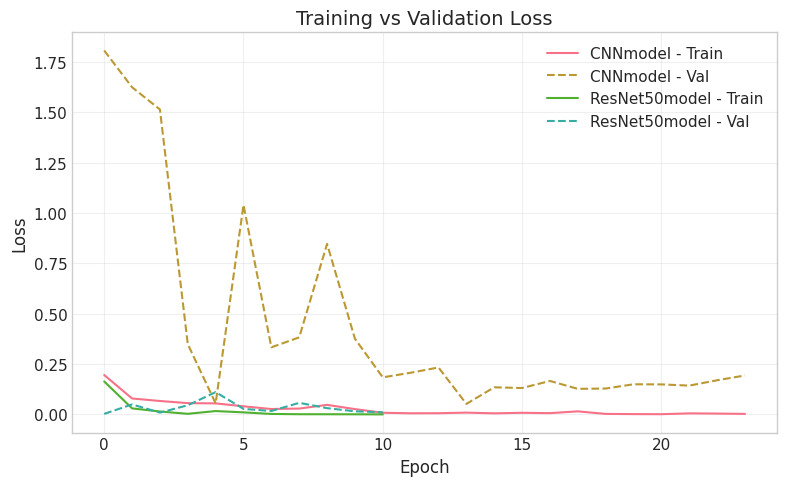

In [30]:
plot_loss_curves(results)

In [31]:
# Plot Accuracy Curves
def plot_accuracy_curves(results):
    if not results:
        raise ValueError("results is empty")

    plt.figure(figsize=(8, 5))
    for entry in results:
        name = entry.get('Modelo', 'Unnamed')
        train_acc = entry.get('Train_Acc', [])
        val_acc = entry.get('Val_Acc', [])
        epochs = entry.get('Epochs_range', list(range(1, len(train_acc) + 1)))

        plt.plot(epochs, train_acc, label=f"{name} - Train")
        plt.plot(epochs, val_acc, linestyle='--', label=f"{name} - Val")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

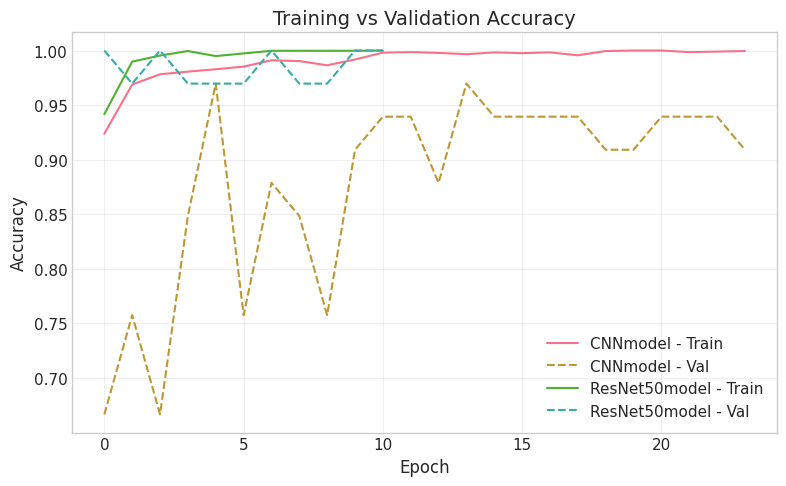

In [32]:
plot_accuracy_curves(results)

Modelo cargado: CNNmodel_all_train_imgs_best.h5


Modelo cargado: ResNet50model_all_train_imgs_best.h5
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step
CNNmodel_all_train_imgs_best.h5 - Test Accuracy: 0.9417
CNNmodel_all_train_imgs_best.h5 - Weighted F1 Score: 0.9421
CNNmodel_all_train_imgs_best.h5 - Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       276
           1       0.97      0.93      0.95        40
           2       0.76      0.80      0.78        44

    accuracy                           0.94       360
   macro avg       0.90      0.90      0.90       360
weighted avg       0.94      0.94      0.94       360



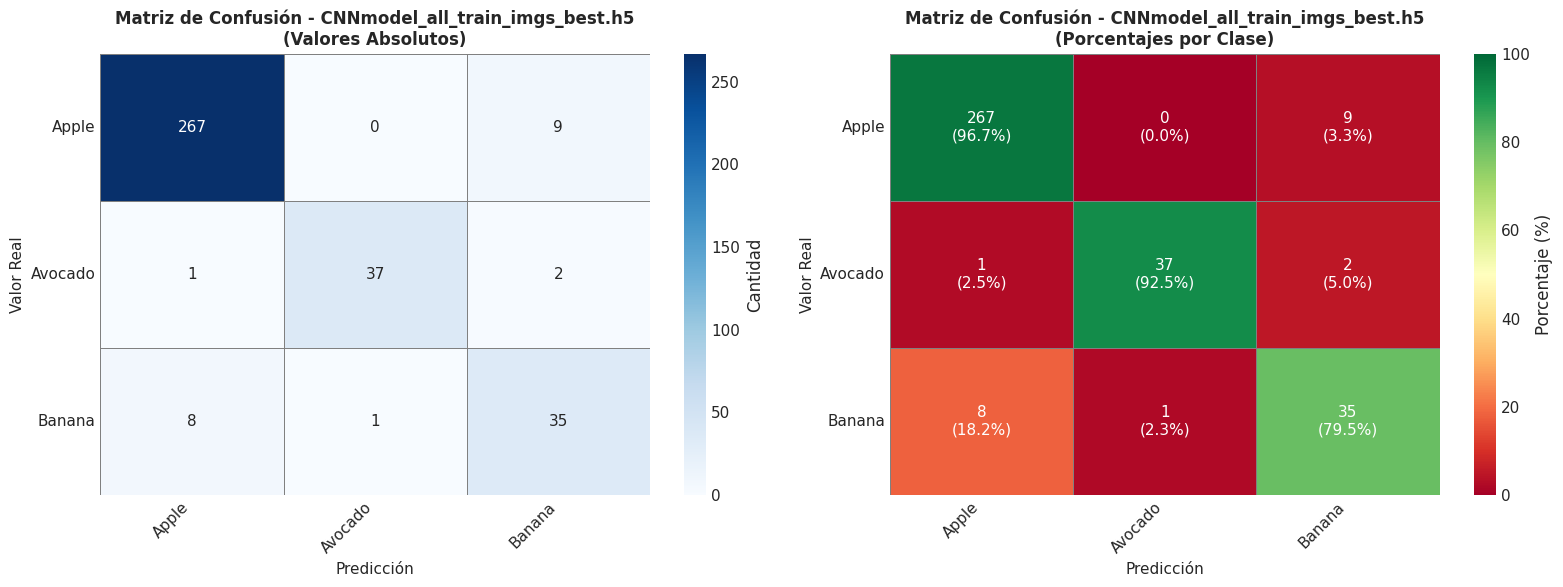


[Estadísticas por Clase - CNNmodel_all_train_imgs_best.h5]
  Apple: 267/276 correctas (96.7%)
  Avocado: 37/40 correctas (92.5%)
  Banana: 35/44 correctas (79.5%)
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 479ms/step
ResNet50model_all_train_imgs_best.h5 - Test Accuracy: 0.9722
ResNet50model_all_train_imgs_best.h5 - Weighted F1 Score: 0.9708
ResNet50model_all_train_imgs_best.h5 - Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       276
           1       1.00      0.78      0.87        40
           2       0.98      0.98      0.98        44

    accuracy                           0.97       360
   macro avg       0.98      0.92      0.94       360
weighted avg       0.97      0.97      0.97       360



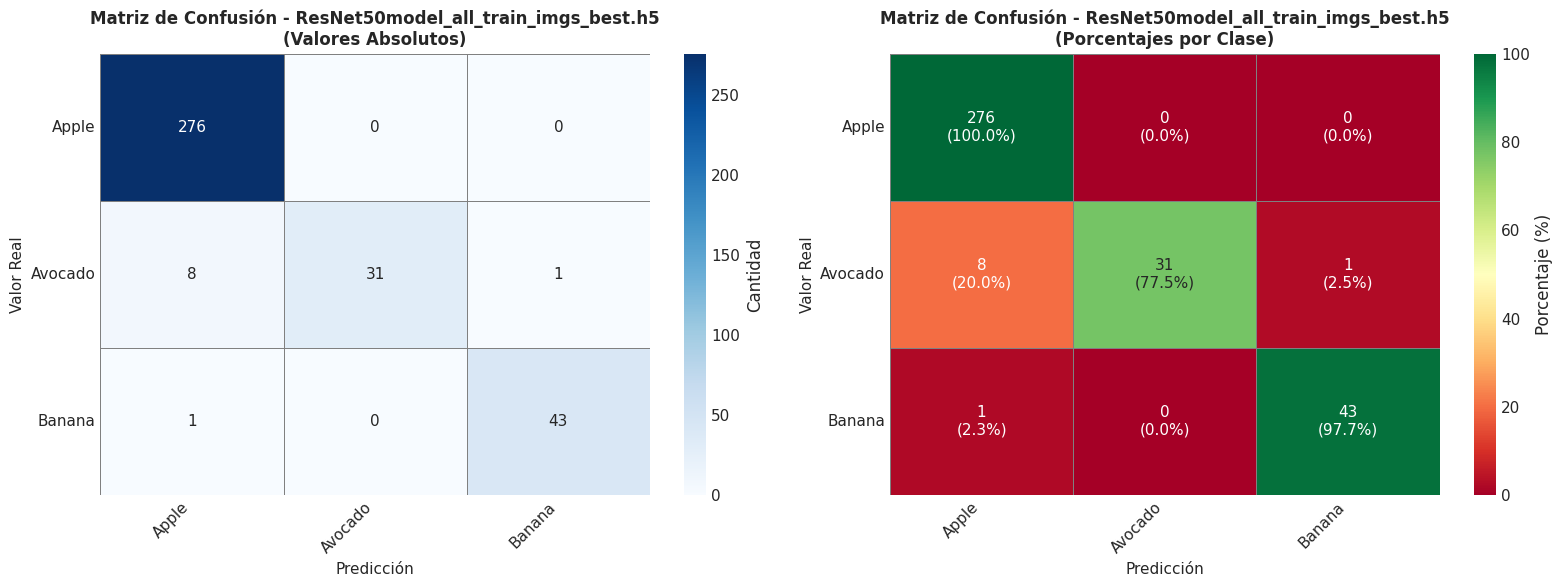


[Estadísticas por Clase - ResNet50model_all_train_imgs_best.h5]
  Apple: 276/276 correctas (100.0%)
  Avocado: 31/40 correctas (77.5%)
  Banana: 43/44 correctas (97.7%)


In [33]:
# Cargar modelos entrenados
model_paths = [r['Modelo'] + '_all_train_imgs_best.h5' for r in results]
loaded_models = {}
for path in model_paths:
    try:
        loaded_models[path] = tf.keras.models.load_model(path)
        print(f"Modelo cargado: {path}")
    except Exception as e:
        print(f"Error al cargar {path}: {e}")

# Evaluar modelos en el set de test
for name, model in loaded_models.items():
    y_probs = model.predict(X_test)
    y_preds = np.argmax(y_probs, axis=1)
    # Accuracy
    test_acc = np.mean(y_preds == y_test)
    print(f"{name} - Test Accuracy: {test_acc:.4f}")
    # Score f1 ponderado
    f1 = f1_score(y_test, y_preds, average='weighted')
    print(f"{name} - Weighted F1 Score: {f1:.4f}")
    # Reporte de clasificación
    # Precision significa = TP / (TP + FP)
    # De las predicciones positivas, cuántas son correctas
    # Recall significa = TP / (TP + FN)
    # De los verdaderos positivos, cuántos fueron correctamente identificados
    # F1 Score = 2 * (Precision * Recall) / (Precision + Recall)
    # Interpretación de F1 Score 
    # - F1 Score cercano a 1: Equilibrio entre precisión y recall
    # - F1 Score cercano a 0: Mala precisión o recall (o ambos)
    print(f"{name} - Classification Report:\n{classification_report(y_test, y_preds)}")

    # ========================================
    # MATRIZ DE CONFUSIÓN MEJORADA
    # ========================================
    cm = confusion_matrix(y_test, y_preds)
    
    # Obtener nombres de las clases
    class_names = [coarse_mapping[i] for i in sorted(np.unique(y_test))]
    
    # Crear figura con 2 subplots: valores absolutos y porcentajes
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Subplot 1: Valores absolutos
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Cantidad'}, ax=axes[0], 
                linewidths=0.5, linecolor='gray')
    axes[0].set_title(f'Matriz de Confusión - {name}\n(Valores Absolutos)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Predicción', fontsize=11)
    axes[0].set_ylabel('Valor Real', fontsize=11)
    
    # Subplot 2: Porcentajes (normalizado por fila)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    # Crear anotaciones personalizadas con valor absoluto y porcentaje
    annot = np.empty_like(cm).astype(str)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f'{cm[i,j]}\n({cm_normalized[i,j]:.1f}%)'
    
    sns.heatmap(cm_normalized, annot=annot, fmt='', cmap='RdYlGn', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Porcentaje (%)'}, ax=axes[1],
                linewidths=0.5, linecolor='gray', vmin=0, vmax=100)
    axes[1].set_title(f'Matriz de Confusión - {name}\n(Porcentajes por Clase)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Predicción', fontsize=11)
    axes[1].set_ylabel('Valor Real', fontsize=11)
    
    # Rotar etiquetas para mejor legibilidad
    for ax in axes:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    # Imprimir estadísticas adicionales por clase
    print(f"\n[Estadísticas por Clase - {name}]")
    for i, class_name in enumerate(class_names):
        total = cm[i].sum()
        correct = cm[i, i]
        accuracy = (correct / total * 100) if total > 0 else 0
        print(f"  {class_name}: {correct}/{total} correctas ({accuracy:.1f}%)")
